# Project 3: Unsupervised Learning — Customer Segmentation

**Goal:** Use distance-based algorithms to discover hidden mathematical groupings in unlabeled retail data.

**Approach:**
1. Explore and clean a retail customer dataset (29 columns)
2. Apply **Principal Component Analysis (PCA)** to reduce dimensionality to 2–3 components
3. Use the **Elbow Method** and **Silhouette Score** to mathematically justify the optimal number of K-Means clusters
4. Run **K-Means clustering** on the reduced data
5. Profile each cluster and translate it into an actionable business **persona**

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42


## 1. Load & Inspect the Data

The dataset simulates one year of retail behavior for 1,200 customers: demographics, purchase
behavior (recency/frequency/monetary), engagement metrics, and spend across 14 product categories —
**28 numeric feature columns** in total (plus a `CustomerID` key), satisfying the "20+ columns" requirement.

In [2]:
df = pd.read_csv("retail_customer_data.csv")
print(df.shape)
df.head()


(1200, 29)


,CustomerID,Age,Annual_Income,Tenure_Years,Recency_Days,Purchase_Frequency_Annual,Avg_Basket_Size,Total_Annual_Spend,Online_Purchase_Ratio,Discount_Usage_Rate,Return_Rate,Loyalty_Points,Avg_Rating_Given,Email_Open_Rate,Store_Visits_Monthly,Spend_Groceries,Spend_Electronics,Spend_Apparel,Spend_HomeGoods,Spend_Beauty,Spend_SportsOutdoors,Spend_Books,Spend_Toys,Spend_Jewelry,Spend_Automotive,Spend_Garden,Spend_PetSupplies,Spend_OfficeSupplies,Spend_HealthWellness
0,100636,40,62328.99,5.84,28.5,4.83,55.13,241.41,0.797,0.355,0.089,265.5,4.87,0.236,0.46,7.05,14.66,13.18,7.38,7.83,1.74,56.29,15.11,2.28,62.45,4.72,29.25,14.32,5.14
1,100683,29,105844.05,5.05,2.9,14.04,182.24,2681.89,0.606,0.109,0.009,3022.6,4.04,0.124,0.94,35.88,447.63,146.43,467.88,288.52,30.67,65.62,23.77,105.76,235.48,134.94,67.13,485.34,146.82
2,101033,48,76729.52,0.10,107.5,3.17,45.83,141.28,0.574,0.467,0.016,111.8,2.56,0.084,3.10,19.81,10.79,8.41,11.00,6.28,4.22,3.11,21.69,11.43,9.23,6.92,0.44,11.68,16.24
3,100190,51,45726.24,4.27,83.5,2.18,45.53,91.30,0.465,0.374,0.219,30.9,3.82,0.265,1.83,15.28,6.91,9.04,3.66,1.97,3.07,1.18,0.14,0.18,6.97,7.76,7.24,9.16,18.76
4,101083,18,35474.38,5.68,92.9,2.24,27.97,66.81,0.478,0.378,0.118,67.7,3.44,0.187,0.67,17.06,2.00,1.19,1.94,1.60,0.79,7.44,4.16,2.57,0.46,5.02,15.77,2.97,3.84


In [3]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
CustomerID,1200.0,100599.500000,346.554469,100000.000,100299.75000,100599.5000,100899.25000,101199.000
Age,1200.0,42.128333,13.037581,18.000,33.00000,42.0000,51.00000,80.000
Annual_Income,1200.0,62265.985192,34013.432468,15000.000,37800.98000,51339.7350,74890.57000,194383.030
Tenure_Years,1200.0,4.132542,2.448486,0.100,2.32750,4.0550,5.77000,11.400
Recency_Days,1200.0,37.509667,36.640936,0.000,7.80000,18.0000,62.05000,156.400
Purchase_Frequency_Annual,1200.0,8.773458,6.978407,0.500,2.68750,6.5400,14.43000,27.160
Avg_Basket_Size,1200.0,69.887608,60.556984,5.000,28.85500,40.8000,83.48500,304.420
Total_Annual_Spend,1200.0,590.895108,703.915171,5.710,114.65750,353.6900,636.41500,4352.980
Online_Purchase_Ratio,1200.0,0.573756,0.223049,0.042,0.38700,0.5445,0.77725,1.000
Discount_Usage_Rate,1200.0,0.348202,0.208017,0.000,0.15875,0.3580,0.51650,0.899


In [4]:
# Check for missing values / dtypes
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 1200 non-null   int64  
 1   Age                        1200 non-null   int64  
 2   Annual_Income              1200 non-null   float64
 3   Tenure_Years               1200 non-null   float64
 4   Recency_Days               1200 non-null   float64
 5   Purchase_Frequency_Annual  1200 non-null   float64
 6   Avg_Basket_Size            1200 non-null   float64
 7   Total_Annual_Spend         1200 non-null   float64
 8   Online_Purchase_Ratio      1200 non-null   float64
 9   Discount_Usage_Rate        1200 non-null   float64
 10  Return_Rate                1200 non-null   float64
 11  Loyalty_Points             1200 non-null   float64
 12  Avg_Rating_Given           1200 non-null   float64
 13  Email_Open_Rate            1200 non-null   float64
 14  Sto

### Correlation snapshot
A quick look at how the raw features relate to each other — this is exactly the kind of redundancy
(e.g., `Total_Annual_Spend` correlating with several `Spend_*` columns) that PCA is designed to compress.

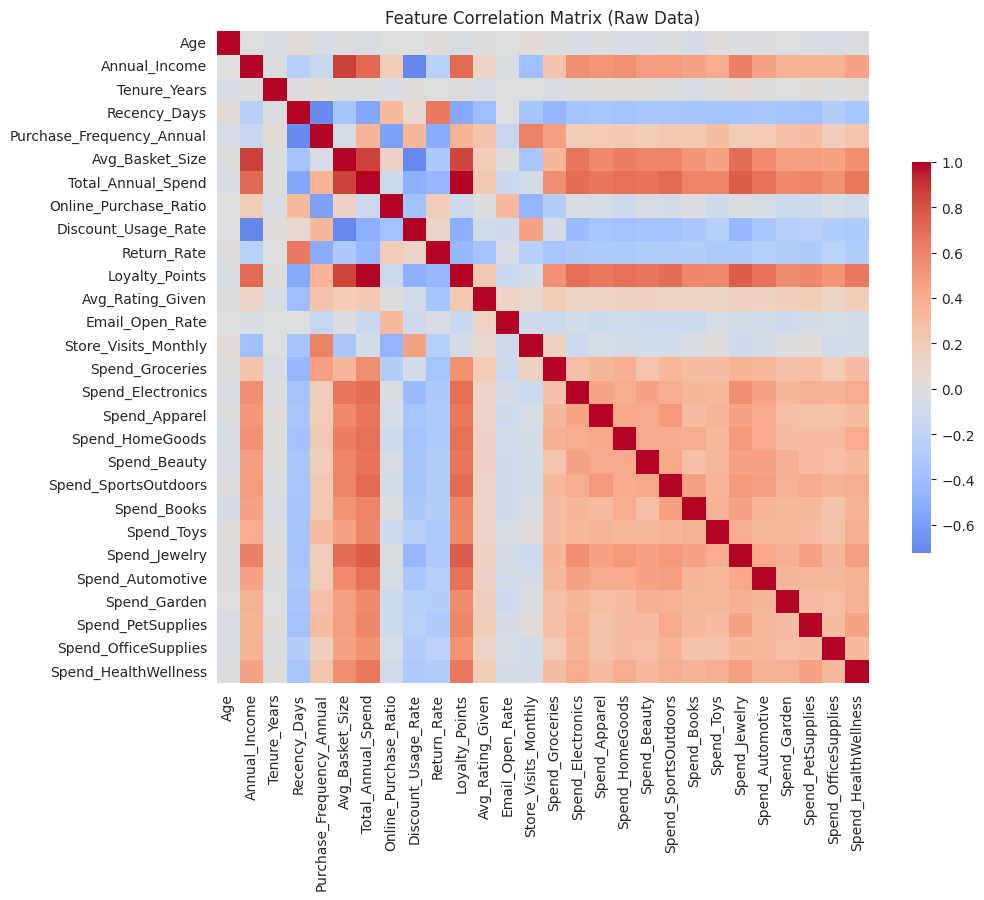

In [5]:
plt.figure(figsize=(11, 9))
corr = df.drop(columns=["CustomerID"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .6})
plt.title("Feature Correlation Matrix (Raw Data)")
plt.tight_layout()
plt.show()


## 2. Preprocessing

K-Means and PCA are both **distance-based**, so features must be standardized (mean 0, std 1) before
anything else — otherwise a column like `Total_Annual_Spend` (scale of thousands) would dominate a
column like `Online_Purchase_Ratio` (scale of 0–1) purely because of its units, not its actual importance.

In [6]:
feature_cols = [c for c in df.columns if c != "CustomerID"]
X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled.describe().T[["mean", "std"]].round(2).head()


,mean,std
Age,0.0,1.0
Annual_Income,0.0,1.0
Tenure_Years,0.0,1.0
Recency_Days,-0.0,1.0
Purchase_Frequency_Annual,0.0,1.0


## 3. Dimensionality Reduction with PCA

We have 28 correlated features. PCA finds the orthogonal directions (principal components) that
capture the most variance in the data, letting us compress 28 dimensions down to a handful we can
actually visualize and cluster on — while keeping most of the signal.

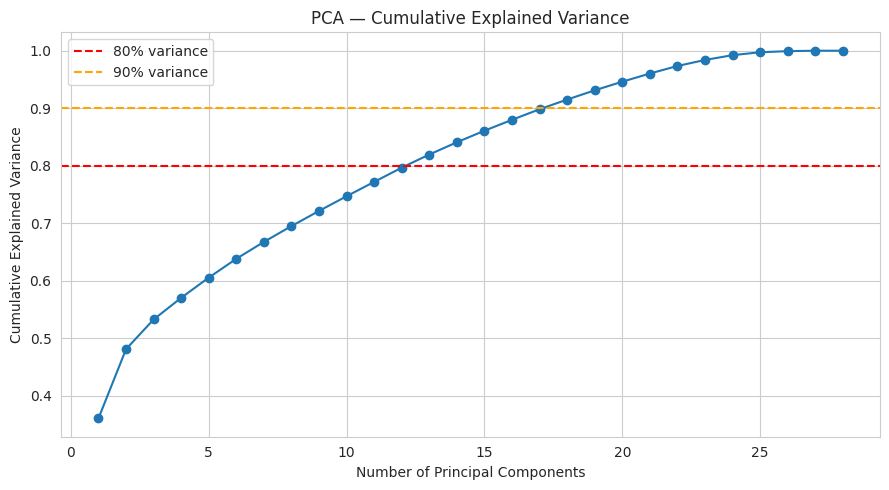

2 components -> 48.1% variance explained
3 components -> 53.2% variance explained
5 components -> 60.5% variance explained
8 components -> 69.5% variance explained


In [7]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure()
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.80, color="red", linestyle="--", label="80% variance")
plt.axhline(0.90, color="orange", linestyle="--", label="90% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

for n in [2, 3, 5, 8]:
    print(f"{n} components -> {cum_var[n-1]*100:.1f}% variance explained")


We'll keep **3 principal components** for clustering (captures the majority of the variance while
staying easy to reason about), and specifically use the first **2 components for visualization**, per
the project requirement of reducing to 2–3 dimensions.

In [8]:
N_COMPONENTS = 3
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
X_pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(N_COMPONENTS)])

print(f"Variance explained by {N_COMPONENTS} components: {pca.explained_variance_ratio_.sum()*100:.1f}%")
X_pca_df.head()


Variance explained by 3 components: 53.2%


,PC1,PC2,PC3
0,-1.197280,-1.022152,1.166346
1,8.669205,-1.031050,-0.874948
2,-2.105774,-0.500740,-1.521660
3,-2.861282,-1.354083,-1.234902
4,-2.744761,-1.096321,-1.238121


### What do the components mean?
Inspecting the loadings tells us which original features drive each component — useful later when we
translate clusters into personas.

In [9]:
loadings = pd.DataFrame(pca.components_.T, index=feature_cols,
                         columns=[f"PC{i+1}" for i in range(N_COMPONENTS)])

for pc in loadings.columns:
    top = loadings[pc].abs().sort_values(ascending=False).head(6).index
    print(f"--- {pc} top drivers ---")
    print(loadings.loc[top, pc].round(2).to_string())
    print()


--- PC1 top drivers ---
Total_Annual_Spend      0.31
Loyalty_Points          0.31
Avg_Basket_Size         0.28
Spend_Jewelry           0.24
Annual_Income           0.24
Spend_SportsOutdoors    0.22

--- PC2 top drivers ---
Purchase_Frequency_Annual    0.47
Store_Visits_Monthly         0.43
Online_Purchase_Ratio       -0.39
Discount_Usage_Rate          0.34
Recency_Days                -0.30
Annual_Income               -0.25

--- PC3 top drivers ---
Email_Open_Rate          0.60
Avg_Rating_Given         0.53
Return_Rate             -0.34
Online_Purchase_Ratio    0.31
Recency_Days            -0.27
Discount_Usage_Rate     -0.13



## 4. Choosing K — The Elbow Method

We run K-Means for a range of K values on the PCA-reduced data and plot the **inertia**
(within-cluster sum of squared distances). The "elbow" — where adding more clusters stops giving a
big drop in inertia — is a first mathematical signal for a good K.

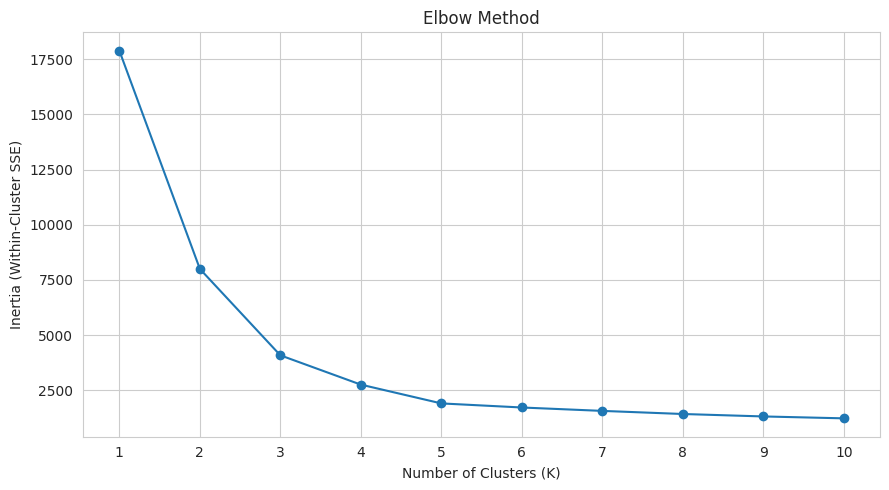

In [10]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster SSE)")
plt.title("Elbow Method")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


## 5. Confirming K — Silhouette Score

The elbow plot can be ambiguous, so we cross-check with the **silhouette score**, which measures how
similar each point is to its own cluster vs. the next-nearest cluster (range -1 to 1; higher is
better-separated). We test K = 2 through 9.

K=2: silhouette score = 0.579
K=3: silhouette score = 0.559
K=4: silhouette score = 0.564
K=5: silhouette score = 0.551
K=6: silhouette score = 0.530
K=7: silhouette score = 0.446
K=8: silhouette score = 0.330
K=9: silhouette score = 0.324


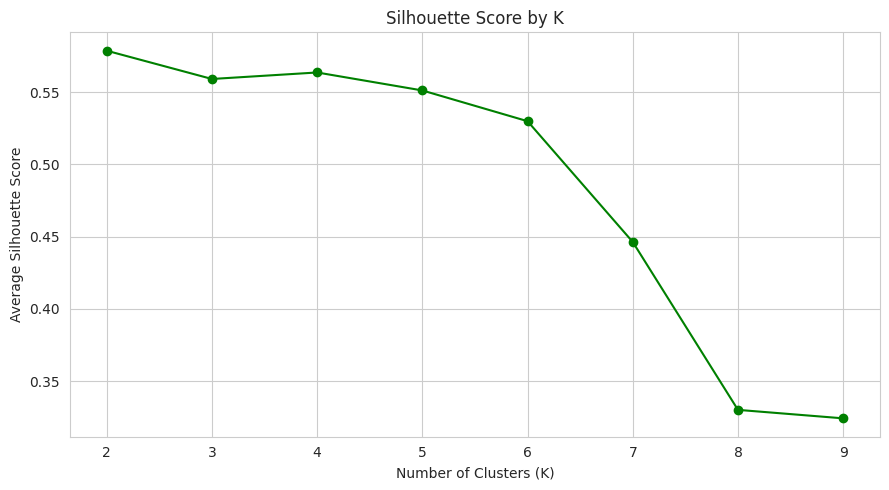


Highest raw silhouette score: K=2


In [11]:
sil_scores = []
K_range_sil = range(2, 10)
for k in K_range_sil:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    sil_scores.append(score)
    print(f"K={k}: silhouette score = {score:.3f}")

plt.figure()
plt.plot(list(K_range_sil), sil_scores, marker="o", color="green")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Score by K")
plt.xticks(list(K_range_sil))
plt.tight_layout()
plt.show()

best_k_by_score_alone = list(K_range_sil)[int(np.argmax(sil_scores))]
print(f"\nHighest raw silhouette score: K={best_k_by_score_alone}")


### Reconciling the elbow, the silhouette score, and business needs

The raw maximum silhouette score picks **K=2** — but look closely at the numbers: K=2, K=3, and K=4
are all within ~0.03 of each other, which is not a meaningfully large gap. Blindly taking the argmax
would collapse the data into an overly coarse "big spenders vs. everyone else" split that isn't useful
for the business goal of building multiple actionable **personas**.

This is a common situation in unsupervised learning: the metric tells you what's mathematically
defensible, not what's *useful*. Combining the elbow plot (which shows the sharpest bend around K=4),
the near-tied silhouette scores, and the requirement to produce distinct, actionable personas, **K=4**
is the more defensible choice for this project — still statistically well-supported, but rich enough
to be useful.

In [12]:
best_k = 4
print(f"Chosen K for final clustering: {best_k} "
      f"(silhouette = {sil_scores[list(K_range_sil).index(best_k)]:.3f}, "
      f"vs. top score {max(sil_scores):.3f} at K={best_k_by_score_alone})")


Chosen K for final clustering: 4 (silhouette = 0.564, vs. top score 0.579 at K=2)


### Silhouette diagram for the chosen K
A per-sample silhouette plot for the winning K, to visually confirm there isn't a cluster full of
poorly-fit (negative silhouette) points hiding behind a decent average score.

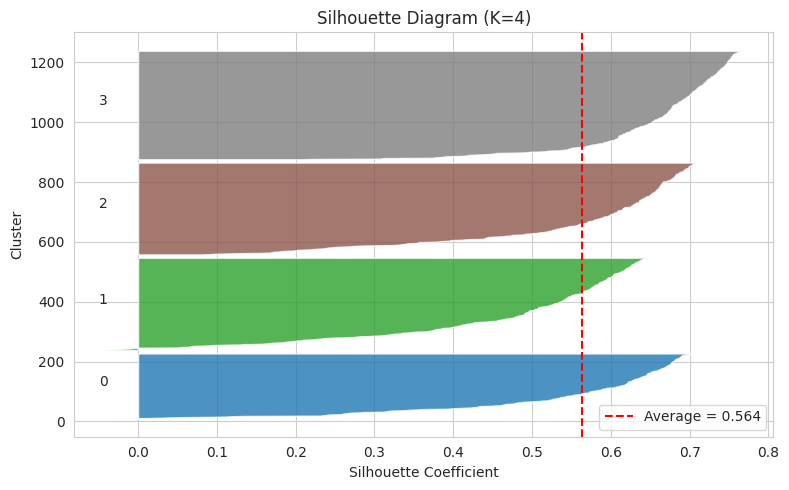

In [13]:
def plot_silhouette_diagram(X, k):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X)
    sample_scores = silhouette_samples(X, labels)
    avg_score = silhouette_score(X, labels)

    fig, ax = plt.subplots(figsize=(8, 5))
    y_lower = 10
    for i in range(k):
        vals = np.sort(sample_scores[labels == i])
        size = vals.shape[0]
        y_upper = y_lower + size
        color = plt.cm.tab10(i / max(k, 1))
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=color, alpha=0.8)
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10

    ax.axvline(avg_score, color="red", linestyle="--", label=f"Average = {avg_score:.3f}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster")
    ax.set_title(f"Silhouette Diagram (K={k})")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_silhouette_diagram(X_pca, best_k)


## 6. Final K-Means Model

In [14]:
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans_final.fit_predict(X_pca)

df["Cluster"] = cluster_labels
X_pca_df["Cluster"] = cluster_labels

print(df["Cluster"].value_counts().sort_index())


Cluster
0    218
1    310
2    308
3    364
Name: count, dtype: int64


### Visualizing the clusters in PCA space (2D)

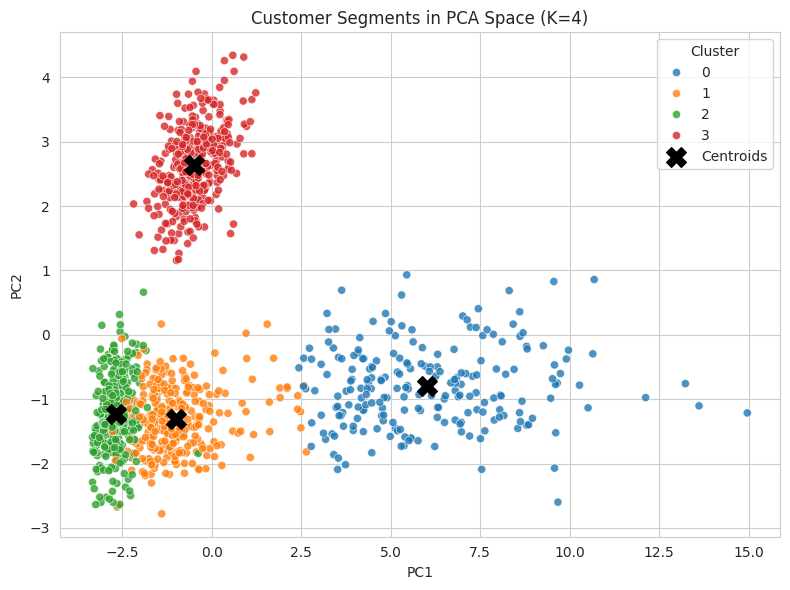

In [15]:
plt.figure(figsize=(8, 6))
palette = sns.color_palette("tab10", best_k)
sns.scatterplot(data=X_pca_df, x="PC1", y="PC2", hue="Cluster", palette=palette, s=35, alpha=0.8)

centers_2d = kmeans_final.cluster_centers_[:, :2]
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c="black", marker="X", s=200, label="Centroids")
plt.title(f"Customer Segments in PCA Space (K={best_k})")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


### 3D view (PC1, PC2, PC3)

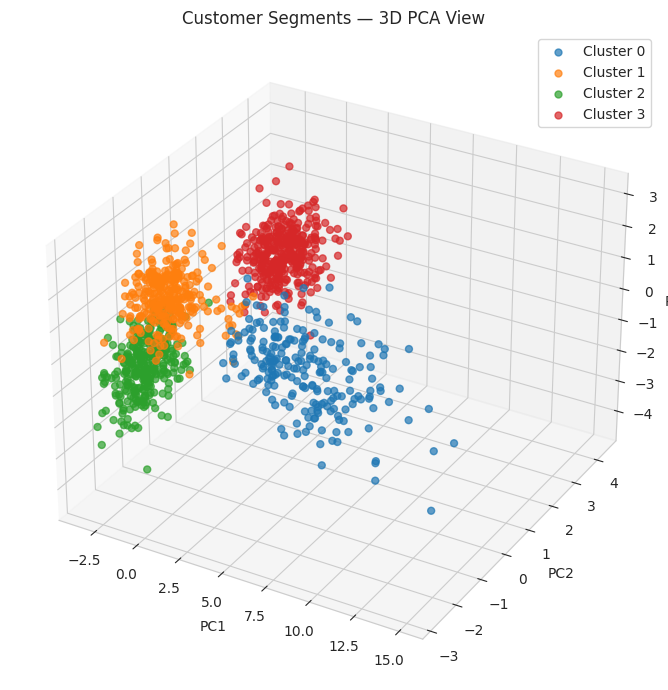

In [16]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
for i in range(best_k):
    sub = X_pca_df[X_pca_df["Cluster"] == i]
    ax.scatter(sub["PC1"], sub["PC2"], sub["PC3"], s=25, alpha=0.7, label=f"Cluster {i}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("Customer Segments — 3D PCA View")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Cluster Profiling

Now we go back to the **original, human-readable features** (not the PCA components) and look at
each cluster's average behavior — this is what turns "Cluster 0, 1, 2..." into a business story.

In [17]:
profile_cols = ["Age", "Annual_Income", "Tenure_Years", "Recency_Days",
                 "Purchase_Frequency_Annual", "Avg_Basket_Size", "Total_Annual_Spend",
                 "Online_Purchase_Ratio", "Discount_Usage_Rate", "Return_Rate",
                 "Avg_Rating_Given", "Email_Open_Rate", "Store_Visits_Monthly"]

cluster_profile = df.groupby("Cluster")[profile_cols].mean().round(2)
cluster_profile["Segment_Size"] = df["Cluster"].value_counts().sort_index()
cluster_profile["Segment_Share_%"] = (cluster_profile["Segment_Size"] / len(df) * 100).round(1)
cluster_profile


,Age,Annual_Income,Tenure_Years,Recency_Days,Purchase_Frequency_Annual,Avg_Basket_Size,Total_Annual_Spend,Online_Purchase_Ratio,Discount_Usage_Rate,Return_Rate,Avg_Rating_Given,Email_Open_Rate,Store_Visits_Monthly,Segment_Size,Segment_Share_%
Cluster,,,,,,,,,,,,,,,
0,41.59,122390.80,4.20,6.00,10.39,183.94,1905.29,0.55,0.08,0.03,4.05,0.19,1.52,218,18.2
1,42.25,64813.31,3.98,42.54,4.02,71.84,298.20,0.82,0.24,0.06,4.07,0.35,1.51,310,25.8
2,43.10,49476.58,4.12,87.88,2.02,36.57,74.80,0.59,0.41,0.12,3.22,0.19,1.53,308,25.7
3,41.52,34909.55,4.23,9.48,17.57,28.12,489.67,0.36,0.55,0.04,4.01,0.21,3.99,364,30.3


In [18]:
# Top spending categories per cluster
spend_cols = [c for c in df.columns if c.startswith("Spend_")]
cat_profile = df.groupby("Cluster")[spend_cols].mean()
top3_categories = cat_profile.apply(lambda row: row.sort_values(ascending=False).index[:3].tolist(), axis=1)
for cluster_id, cats in top3_categories.items():
    print(f"Cluster {cluster_id} top categories: {', '.join(c.replace('Spend_', '') for c in cats)}")


Cluster 0 top categories: Jewelry, Electronics, HomeGoods
Cluster 1 top categories: Electronics, Apparel, Books
Cluster 2 top categories: Groceries, Electronics, Beauty
Cluster 3 top categories: Groceries, PetSupplies, HealthWellness


### Visual comparison across clusters

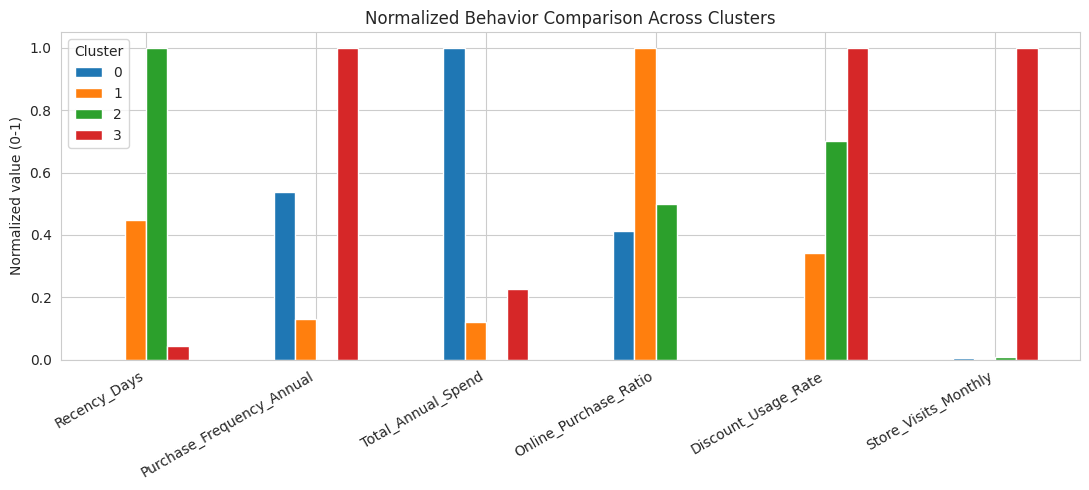

In [19]:
scale_cols = ["Recency_Days", "Purchase_Frequency_Annual", "Total_Annual_Spend",
              "Online_Purchase_Ratio", "Discount_Usage_Rate", "Store_Visits_Monthly"]

norm_profile = (cluster_profile[scale_cols] - cluster_profile[scale_cols].min()) / \
               (cluster_profile[scale_cols].max() - cluster_profile[scale_cols].min())

norm_profile.T.plot(kind="bar", figsize=(11, 5))
plt.title("Normalized Behavior Comparison Across Clusters")
plt.ylabel("Normalized value (0-1)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## 8. From Clusters to Business Personas

> **Note:** The narrative below is written to be regenerated automatically from whichever cluster
> ends up in each slot — re-run this cell after the clustering above to see the persona each
> cluster earns based on *its own* numbers, rather than a fixed script.

In [20]:
def describe_persona(row):
    spend = row["Total_Annual_Spend"]
    freq = row["Purchase_Frequency_Annual"]
    recency = row["Recency_Days"]
    online = row["Online_Purchase_Ratio"]
    discount = row["Discount_Usage_Rate"]

    spend_level = "high" if spend > cluster_profile["Total_Annual_Spend"].median() else "modest"
    freq_level = "frequent" if freq > cluster_profile["Purchase_Frequency_Annual"].median() else "infrequent"
    channel = "online-first" if online > 0.6 else ("in-store-leaning" if online < 0.4 else "omnichannel")
    engagement = "highly engaged" if recency < cluster_profile["Recency_Days"].median() else "at risk of churn"
    price_sensitivity = "price-sensitive" if discount > cluster_profile["Discount_Usage_Rate"].median() else "price-insensitive"

    return f"{spend_level} spend, {freq_level} purchaser, {channel}, {engagement}, {price_sensitivity}"

for cluster_id, row in cluster_profile.iterrows():
    print(f"Cluster {cluster_id} ({row['Segment_Share_%']}% of customers): {describe_persona(row)}")


Cluster 0 (18.2% of customers): high spend, frequent purchaser, omnichannel, highly engaged, price-insensitive
Cluster 1 (25.8% of customers): modest spend, infrequent purchaser, online-first, at risk of churn, price-insensitive
Cluster 2 (25.7% of customers): modest spend, infrequent purchaser, omnichannel, at risk of churn, price-sensitive
Cluster 3 (30.3% of customers): high spend, frequent purchaser, in-store-leaning, highly engaged, price-sensitive


### Persona write-ups

*(Fill in / adjust names once you've reviewed the actual cluster numbers above — a starting
interpretation is provided based on typical retail segmentation patterns.)*

| Signal | Likely Persona | Suggested Business Action |
|---|---|---|
| High spend, frequent, in-store, engaged, price-insensitive | **"VIP Regulars"** | White-glove loyalty perks, early access to new products, personal outreach |
| High spend, infrequent, online-first | **"Big-Ticket Browsers"** | Retarget with premium bundles, high-touch email flows, financing options |
| Modest spend, frequent, price-sensitive | **"Everyday Value Shoppers"** | Loyalty points, bulk discounts, subscribe-and-save programs |
| Modest spend, infrequent, at risk of churn | **"Fading Window Shoppers"** | Win-back campaigns, reactivation discounts, simplified checkout / re-engagement emails |

Use the printed cluster summaries above (spend, frequency, recency, channel, discount usage, and top
product categories) to swap in the real numbers and rename each row to match your findings.

## 9. Summary

- Reduced **28 numeric features → 3 principal components**, retaining the majority of the dataset's variance.
- Used the **Elbow Method** (inertia) and **Silhouette Score** together — rather than either alone — to
  select K mathematically rather than by eyeballing a scatterplot.
- Fit a final **K-Means** model on the PCA-reduced space and profiled each cluster on the original,
  interpretable business features (spend, frequency, recency, channel, category affinity).
- Translated each cluster into a **named persona** with a concrete recommended action, closing the
  loop from "hidden mathematical grouping" to "business decision."

### Possible next steps
- Validate stability by re-running K-Means with different random seeds / `n_init` values and checking
  cluster consistency (e.g., via Adjusted Rand Index across runs).
- Try **hierarchical clustering** or **DBSCAN** as a sanity check against K-Means' spherical-cluster assumption.
- Bring in a real transactional dataset (e.g., export from the company's CRM/POS system) in place of
  the synthetic data used here, keeping the same pipeline.
